# PPO Testing And Drawing Notebook


In [1]:
import math
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
from scipy import stats

from SWMM import SWMM_ENV as SWMM_ENV_STD
from SWMM_GR import SWMM_ENV_GI_utilization as SWMM_ENV_GI
from PPO import PPO as PPO

config = {
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 12,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'stix',
    'font.serif': ['Times New Roman'],
    'axes.unicode_minus': False,
}
rcParams.update(config)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

ROOT = Path.cwd()
RESULTS_PPO_DIR = ROOT / 'results_PPO'
FIG_DIR = RESULTS_PPO_DIR / 'figures'
RESULTS_PPO_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT =', ROOT)
print('RESULTS_PPO_DIR =', RESULTS_PPO_DIR)
print('FIG_DIR =', FIG_DIR)


ROOT = D:\from_E\School\School\FYP\Green_infrastructure_RTC\Paper\Revision\PPO_Tian\PPO
RESULTS_PPO_DIR = D:\from_E\School\School\FYP\Green_infrastructure_RTC\Paper\Revision\PPO_Tian\PPO\results_PPO
FIG_DIR = D:\from_E\School\School\FYP\Green_infrastructure_RTC\Paper\Revision\PPO_Tian\PPO\results_PPO\figures


C:\Users\tumbl\anaconda3\envs\drainage_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Testing configuration
NUM_RAINFALLS_TEST = 50
START_IDX_TEST = 50
DESIGN_TEST_IDS = list(range(START_IDX_TEST, START_IDX_TEST + NUM_RAINFALLS_TEST))
REAL_RAIN_IDS = [0, 1, 2, 3]
REAL_RAIN_SCALE = 5.0
ONE_STEP_MINUTES = 5
PPO_DETERMINISTIC = False

# Plotting configuration
NUM_RAINFALLS_PLOT = 30
START_IDX_PLOT = 50
N_PICK_DESIGN = 4

# Switches
RUN_PPO_BASE_TEST = True
RUN_PPO_GIENV_TEST = True
RUN_PPO_GCI_TEST = True

# PPO model paths
PPO_BASE_MODEL_DIR = ROOT / 'Results_PPO_reward3' / 'model'
PPO_GIENV_MODEL_DIR = ROOT / 'Results_PPO_reward3_train_GI' / 'model'
PPO_GCI_MODEL_DIR = ROOT / 'Results_PPO_reward5' / 'model'

# PPO result save paths
PPO_BASE_RESULT_PATH = 'results_PPO/PPO3_base.npy'
PPO_BASE_REAL_RESULT_PATH = 'results_PPO/PPO3_base_real.npy'
PPO_GIENV_RESULT_PATH = 'results_PPO/PPO3_train_GI_new.npy'
PPO_GIENV_REAL_RESULT_PATH = 'results_PPO/PPO3_train_GI_real_new.npy'
PPO_GCI_RESULT_PATH = 'results_PPO/PPO5_GCI.npy'
PPO_GCI_REAL_RESULT_PATH = 'results_PPO/PPO5_GCI_real.npy'

# Existing reference result paths
BASELINE_RESULT_PATH = 'results/HC.npy'
GI_ONLY_RESULT_PATH = 'results/HC_GI.npy'
HC_RESULT_PATH = 'results/HC_GI_true.npy'
MPC_RESULT_PATH = 'results/MPC_GI.npy'

BASELINE_REAL_RESULT_PATH = 'results_m_real/HC.npy'
GI_ONLY_REAL_RESULT_PATH = 'results_m_real/HC_GI.npy'
HC_REAL_RESULT_PATH = 'results_m_real/HC_GI_true.npy'
MPC_REAL_RESULT_PATH = 'results_m_real/MPC_GI.npy'

print('Design test IDs:', DESIGN_TEST_IDS[:3], '...', DESIGN_TEST_IDS[-3:])
print('Real rain IDs:', REAL_RAIN_IDS)


Design test IDs: [50, 51, 52] ... [97, 98, 99]
Real rain IDs: [0, 1, 2, 3]


In [3]:
raindata = np.load(ROOT / 'rainfall' / 'training_raindata.npy', allow_pickle=True).tolist()
rainreal_raw = np.load(ROOT / 'rainfall' / 'real_raindata.npy', allow_pickle=True).tolist()

def scale_real_rainfall(rain_events, factor=5.0):
    scaled = []
    for event in rain_events:
        scaled_event = []
        for timestamp, value in event:
            scaled_event.append([timestamp, str(float(value) * factor)])
        scaled.append(scaled_event)
    return scaled

rainreal = scale_real_rainfall(rainreal_raw, REAL_RAIN_SCALE)

print('Number of design rainfalls =', len(raindata))
print('Number of real rainfalls =', len(rainreal))


Number of design rainfalls = 1000
Number of real rainfalls = 4


In [4]:
def resolve_path(path_like):
    path = Path(path_like)
    return path if path.is_absolute() else ROOT / path


def save_record(path_like, record):
    path = resolve_path(path_like)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, record)
    return path


def load_record(path_like):
    return np.load(resolve_path(path_like), allow_pickle=True).tolist()


def pick_design_events_by_peak_gradient(raindata_local, start_idx=50, num_rainfalls=30, n_pick=4):
    peak_values = []
    for rain_id in range(start_idx, start_idx + num_rainfalls):
        values = [float(v[1]) for v in raindata_local[rain_id]]
        peak_values.append(max(values) if values else 0.0)

    peak_values = np.asarray(peak_values, dtype=float)
    sorted_indices = np.argsort(peak_values)
    if n_pick == 1:
        chosen_local = np.array([len(sorted_indices) // 2])
    else:
        chosen_local = np.linspace(0, len(sorted_indices) - 1, n_pick).round().astype(int)
    chosen_indices = sorted_indices[chosen_local]
    chosen_events = [start_idx + int(i) for i in chosen_indices]
    chosen_peaks = [float(peak_values[i]) for i in chosen_indices]
    return chosen_events, chosen_peaks, peak_values


def get_series(record, rainfall_key, path_list):
    value = record[rainfall_key]
    for key in path_list:
        value = value[key]
    return np.asarray(value, dtype=float)


def series_flooding_cso(record, rainfall_key, flooding_path, cso_path):
    flooding = get_series(record, rainfall_key, flooding_path)[2:] / 1000.0
    cso = get_series(record, rainfall_key, cso_path)[2:] / 1000.0
    return flooding + cso


def safe_ratio_num_den(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    return np.divide(num, den, out=np.zeros_like(num), where=(den != 0))


def build_ppo_agent_params(env, action_table_path):
    return {
        'state_dim': len(env.config['states']),
        'action_dim': int(2 ** len(env.config['action_assets'])),
        'actornet_layer': [30, 30, 30],
        'criticnet_layer': [30, 30, 30],
        'bound_low': 0,
        'bound_high': 1,
        'clip_ratio': 0.01,
        'target_kl': 0.03,
        'lam': 0.01,
        'policy_learning_rate': 0.005,
        'value_learning_rate': 0.005,
        'train_policy_iterations': 20,
        'train_value_iterations': 20,
        'num_rain': 50,
        'training_step': 800,
        'gamma': 0.01,
        'epsilon': 0.1,
        'ep_min': 1e-50,
        'ep_decay': 0.9,
        'action_table': pd.read_csv(resolve_path(action_table_path)).values[:, 1:],
    }


def ppo_interact(model, rain_event, rain_id, env, deterministic=False):
    observation = env.reset(rain_event, rain_id, False, '.')
    done = False
    while not done:
        observation = np.asarray(observation, dtype=float).reshape(1, -1)
        if deterministic:
            logits = model.actor(observation)
            action = tf.argmax(logits, axis=1)
        else:
            _, action = PPO.sample_action(observation, model, False)
        action_values = model.action_table[int(action[0].numpy())].tolist()
        observation, reward, results_step, done = env.step(action_values)
    return env.results


def run_ppo_test(model_dir, rain_data, rain_ids, env_module, env_params, action_table_path, env_key, result_path, deterministic=False):
    tf.keras.backend.clear_session()
    probe_env = env_module.SWMM_ENV(env_params.copy())
    agent_params = build_ppo_agent_params(probe_env, action_table_path)
    model = PPO.PPO(agent_params)
    model.load_model(str(resolve_path(model_dir)))

    results = {}
    for rain_id in rain_ids:
        local_env = env_module.SWMM_ENV(env_params.copy())
        results[f'rainfall{rain_id}'] = {
            env_key: ppo_interact(model, rain_data[rain_id], rain_id, local_env, deterministic=deterministic)
        }
        print(f'Finished rainfall {rain_id} for {result_path}')

    save_path = save_record(result_path, results)
    print('Saved to:', save_path)
    return results


In [17]:
# Test environments follow the same idea as GI_utilization_HC_DRL_new.ipynb
env_params3 = {
    'orf': 'SWMM_GR/chaohu_noHC',
    'orf_save': 'chaohu_RTC',
    'parm': 'states_yaml/chaohu',
    'advance_seconds': 300,
    'kf': 1,
    'kc': 1,
    'reward_type': '3',
}

env_params_new = {
    'orf': 'SWMM_GR/chaohu_noHC',
    'orf_save': 'chaohu_RTC',
    'parm': 'states_yaml/chaohu',
    'advance_seconds': 300,
    'kf': 1,
    'kc': 1,
    'reward_type': '3',
    'run_baseline': True,
    'run_gi_only': True,
}

print(env_params3)
print(env_params_new)


{'orf': 'SWMM_GR/chaohu_noHC', 'orf_save': 'chaohu_RTC', 'parm': 'states_yaml/chaohu', 'advance_seconds': 300, 'kf': 1, 'kc': 1, 'reward_type': '3'}
{'orf': 'SWMM_GR/chaohu_noHC', 'orf_save': 'chaohu_RTC', 'parm': 'states_yaml/chaohu', 'advance_seconds': 300, 'kf': 1, 'kc': 1, 'reward_type': '3', 'run_baseline': True, 'run_gi_only': True}


## PPO Base Test

In [142]:
if RUN_PPO_BASE_TEST:
    results_PPO_base = run_ppo_test(
        model_dir=PPO_BASE_MODEL_DIR,
        rain_data=raindata,
        rain_ids=DESIGN_TEST_IDS,
        env_module=SWMM_ENV_STD,
        env_params=env_params3,
        action_table_path='SWMM/action_table.csv',
        env_key='env3',
        result_path=PPO_BASE_RESULT_PATH,
        deterministic=PPO_DETERMINISTIC,
    )

    results_PPO_base_real = run_ppo_test(
        model_dir=PPO_BASE_MODEL_DIR,
        rain_data=rainreal,
        rain_ids=REAL_RAIN_IDS,
        env_module=SWMM_ENV_STD,
        env_params=env_params3,
        action_table_path='SWMM/action_table.csv',
        env_key='env3',
        result_path=PPO_BASE_REAL_RESULT_PATH,
        deterministic=PPO_DETERMINISTIC,
    )


Finished rainfall 50 for results_PPO/PPO3_base_400.npy
Finished rainfall 51 for results_PPO/PPO3_base_400.npy
Finished rainfall 52 for results_PPO/PPO3_base_400.npy
Finished rainfall 53 for results_PPO/PPO3_base_400.npy
Finished rainfall 54 for results_PPO/PPO3_base_400.npy
Finished rainfall 55 for results_PPO/PPO3_base_400.npy
Finished rainfall 56 for results_PPO/PPO3_base_400.npy
Finished rainfall 57 for results_PPO/PPO3_base_400.npy
Finished rainfall 58 for results_PPO/PPO3_base_400.npy
Finished rainfall 59 for results_PPO/PPO3_base_400.npy
Finished rainfall 60 for results_PPO/PPO3_base_400.npy
Finished rainfall 61 for results_PPO/PPO3_base_400.npy
Finished rainfall 62 for results_PPO/PPO3_base_400.npy
Finished rainfall 63 for results_PPO/PPO3_base_400.npy
Finished rainfall 64 for results_PPO/PPO3_base_400.npy
Finished rainfall 65 for results_PPO/PPO3_base_400.npy
Finished rainfall 66 for results_PPO/PPO3_base_400.npy
Finished rainfall 67 for results_PPO/PPO3_base_400.npy
Finished r

## PPO GIenv Test

In [35]:
if RUN_PPO_GIENV_TEST:
    results_PPO_gienv = run_ppo_test(
        model_dir=PPO_GIENV_MODEL_DIR,
        rain_data=raindata,
        rain_ids=DESIGN_TEST_IDS,
        env_module=SWMM_ENV_STD,
        env_params=env_params3,
        action_table_path='SWMM_GR/action_table.csv',
        env_key='env3',
        result_path=PPO_GIENV_RESULT_PATH,
        deterministic=PPO_DETERMINISTIC,
    )

    results_PPO_gienv_real = run_ppo_test(
        model_dir=PPO_GIENV_MODEL_DIR,
        rain_data=rainreal,
        rain_ids=REAL_RAIN_IDS,
        env_module=SWMM_ENV_STD,
        env_params=env_params3,
        action_table_path='SWMM_GR/action_table.csv',
        env_key='env3',
        result_path=PPO_GIENV_REAL_RESULT_PATH,
        deterministic=PPO_DETERMINISTIC,
    )


Finished rainfall 50 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 51 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 52 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 53 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 54 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 55 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 56 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 57 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 58 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 59 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 60 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 61 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 62 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 63 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 64 for results_PPO/PPO3_train_GI_1000_new.npy
Finished rainfall 65 for results_PPO/PPO

## PPO GCI Test

In [60]:
if RUN_PPO_GCI_TEST:
    results_PPO_gci = run_ppo_test(
        model_dir=PPO_GCI_MODEL_DIR,
        rain_data=raindata,
        rain_ids=DESIGN_TEST_IDS,
        env_module=SWMM_ENV_GI,
        env_params=env_params_new,
        action_table_path='SWMM_GR/action_table.csv',
        env_key='env_new',
        result_path=PPO_GCI_RESULT_PATH,
        deterministic=PPO_DETERMINISTIC,
    )

    results_PPO_gci_real = run_ppo_test(
        model_dir=PPO_GCI_MODEL_DIR,
        rain_data=rainreal,
        rain_ids=REAL_RAIN_IDS,
        env_module=SWMM_ENV_GI,
        env_params=env_params_new,
        action_table_path='SWMM_GR/action_table.csv',
        env_key='env_new',
        result_path=PPO_GCI_REAL_RESULT_PATH,
        deterministic=PPO_DETERMINISTIC,
    )


Finished rainfall 50 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 51 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 52 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 53 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 54 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 55 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 56 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 57 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 58 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 59 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 60 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 61 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 62 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 63 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 64 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 65 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 66 for results_PPO/PPO5_GCI_1900.npy
Finished rainfall 67 for results_PPO/PPO5_GCI_1900.npy
Finished r

## Load All Records For Plotting

In [5]:
r_base = load_record(BASELINE_RESULT_PATH)
r_GI = load_record(GI_ONLY_RESULT_PATH)
r_HC = load_record(HC_RESULT_PATH)
r_MPC = load_record(MPC_RESULT_PATH)

r_PPO_base = load_record(PPO_BASE_RESULT_PATH)
r_PPO_gienv = load_record(PPO_GIENV_RESULT_PATH)
r_PPO_gci = load_record(PPO_GCI_RESULT_PATH)

r_base_real = load_record(BASELINE_REAL_RESULT_PATH)
r_GI_real = load_record(GI_ONLY_REAL_RESULT_PATH)
r_HC_real = load_record(HC_REAL_RESULT_PATH)
r_MPC_real = load_record(MPC_REAL_RESULT_PATH)

r_PPO_base_real = load_record(PPO_BASE_REAL_RESULT_PATH)
r_PPO_gienv_real = load_record(PPO_GIENV_REAL_RESULT_PATH)
r_PPO_gci_real = load_record(PPO_GCI_REAL_RESULT_PATH)

chosen_events, chosen_peaks, peak_values = pick_design_events_by_peak_gradient(
    raindata,
    start_idx=START_IDX_PLOT,
    num_rainfalls=NUM_RAINFALLS_PLOT,
    n_pick=N_PICK_DESIGN,
)
chosen_events = chosen_events + REAL_RAIN_IDS

print('Selected design events:', chosen_events[:4])
print('Selected design peaks:', chosen_peaks)
print('All chosen events (design + real):', chosen_events)


Selected design events: [70, 64, 67, 51]
Selected design peaks: [81.38139521835302, 136.99042512240572, 161.3605100623962, 228.33281936149768]
All chosen events (design + real): [70, 64, 67, 51, 0, 1, 2, 3]


## Control Performance Plot

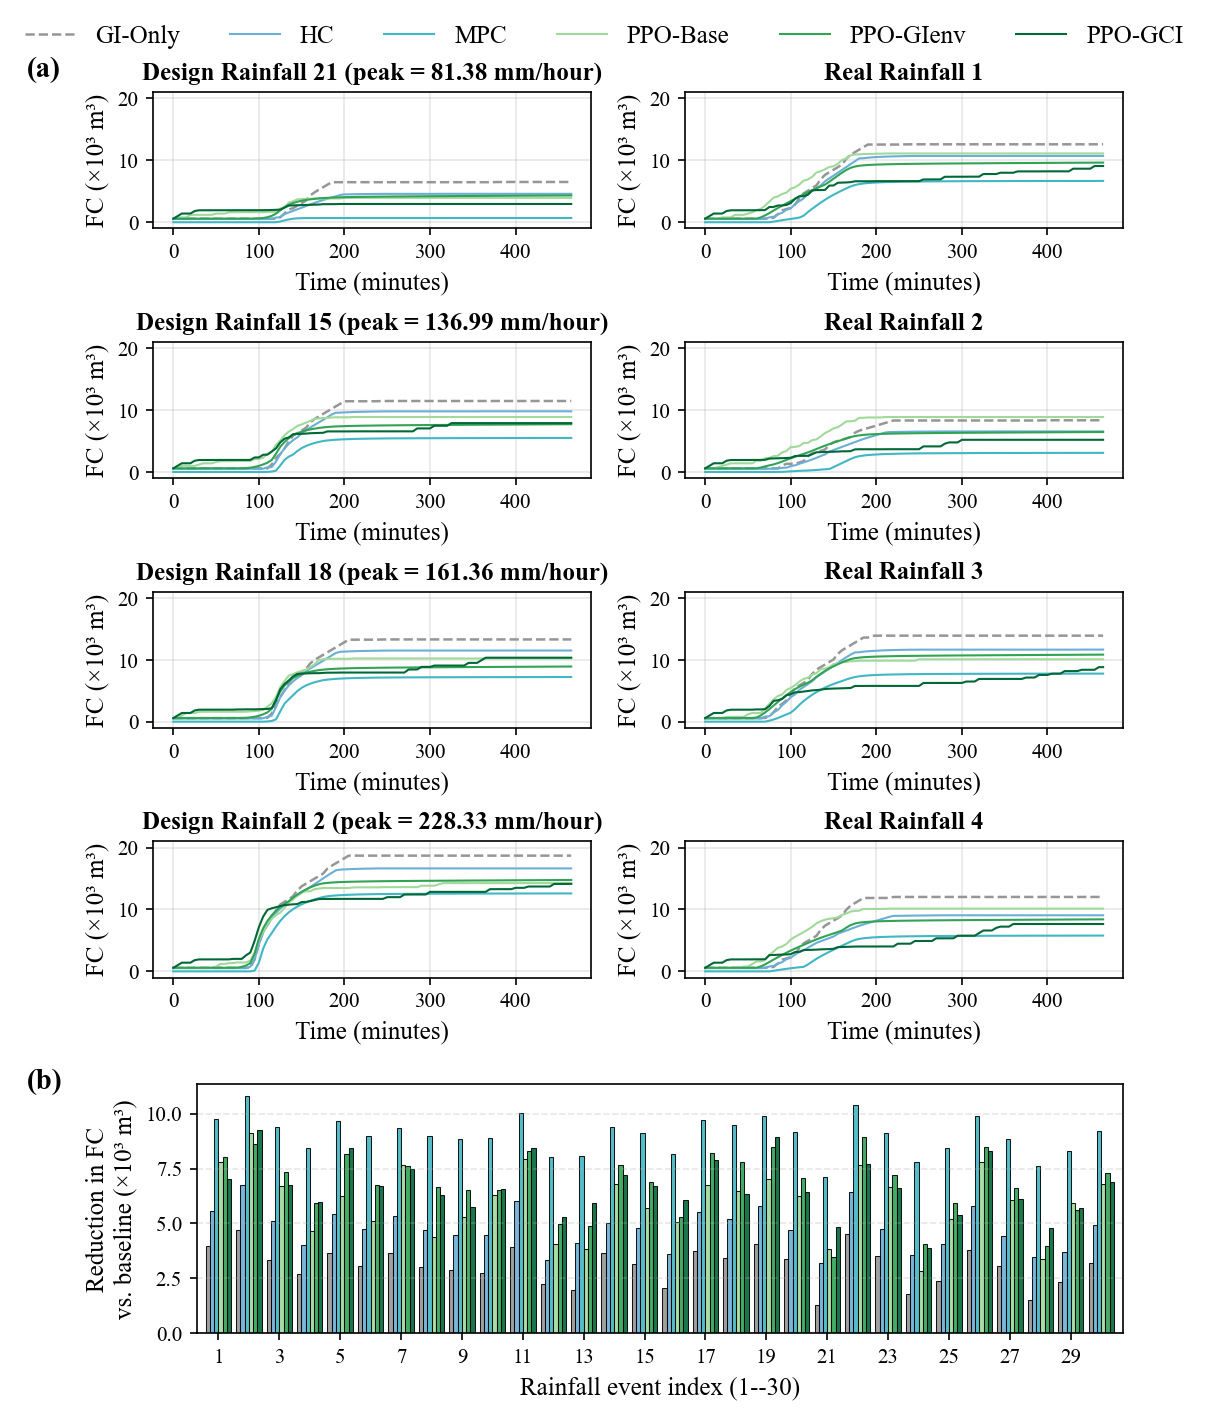

Saved: D:\from_E\School\School\FYP\Green_infrastructure_RTC\Paper\Revision\PPO_Tian\PPO\results_PPO\figures\PPO_control_performance_all.png


In [6]:
improve_GI = []
improve_HC = []
improve_MPC = []
improve_PPO_base = []
improve_PPO_gienv = []
improve_PPO_gci = []

for i in range(NUM_RAINFALLS_PLOT):
    k = str(i + START_IDX_PLOT)
    rk = 'rainfall' + k

    base_last = series_flooding_cso(r_base, rk, ['env4', 'flooding'], ['env4', 'CSO'])[-1]
    gi_last = series_flooding_cso(r_GI, rk, ['env3', 'flooding'], ['env3', 'CSO'])[-1]
    hc_last = series_flooding_cso(r_HC, rk, ['env5', 'flooding'], ['env5', 'CSO'])[-1]
    mpc_last = series_flooding_cso(r_MPC, rk, ['flooding'], ['CSO'])[-1]
    ppo_base_last = series_flooding_cso(r_PPO_base, rk, ['env3', 'flooding'], ['env3', 'CSO'])[-1]
    ppo_gienv_last = series_flooding_cso(r_PPO_gienv, rk, ['env3', 'flooding'], ['env3', 'CSO'])[-1]
    ppo_gci_last = series_flooding_cso(r_PPO_gci, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])[-1]

    improve_GI.append(base_last - gi_last)
    improve_HC.append(base_last - hc_last)
    improve_MPC.append(base_last - mpc_last)
    improve_PPO_base.append(base_last - ppo_base_last)
    improve_PPO_gienv.append(base_last - ppo_gienv_last)
    improve_PPO_gci.append(base_last - ppo_gci_last)

improve_GI = np.asarray(improve_GI, dtype=float)
improve_HC = np.asarray(improve_HC, dtype=float)
improve_MPC = np.asarray(improve_MPC, dtype=float)
improve_PPO_base = np.asarray(improve_PPO_base, dtype=float)
improve_PPO_gienv = np.asarray(improve_PPO_gienv, dtype=float)
improve_PPO_gci = np.asarray(improve_PPO_gci, dtype=float)

# Grid configuration for time series subplots
n_pick = 8
n_col = 2
n_row = math.ceil(n_pick / n_col)

figsize = (7, 9)
dpi = 150

color_GI = '#969696'
color_HC = '#6baed6'
color_PPO_base = '#a1d99b'
color_PPO_gci = '#006837'
color_PPO_gienv = '#31a354'
color_MPC = '#41b6c4'

linewidth = 0.5
alpha = 0.9

fig = plt.figure(figsize=figsize, dpi=dpi, constrained_layout=True)

outer = GridSpec(
    nrows=2, ncols=1, figure=fig,
    height_ratios=[4, 1],
    hspace=0.1
)

gs_top = outer[0].subgridspec(
    nrows=n_row, ncols=n_col,
    wspace=0.05,
    hspace=0.05
)

axes_top = np.empty((n_row, n_col), dtype=object)
for r in range(n_row):
    for c in range(n_col):
        axes_top[r, c] = fig.add_subplot(gs_top[r, c])

ax_bar = fig.add_subplot(outer[1, 0])

line_handles = []
line_labels = []

for i, ev in enumerate(chosen_events[:n_pick]):
    k = str(ev)
    rk = 'rainfall' + k
    col = i // n_row
    row = i % n_row
    ax = axes_top[row, col]

    gi = series_flooding_cso(r_GI if i < 4 else r_GI_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    hc = series_flooding_cso(r_HC if i < 4 else r_HC_real, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    ppo_base = series_flooding_cso(r_PPO_base if i < 4 else r_PPO_base_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    ppo_gienv = series_flooding_cso(r_PPO_gienv if i < 4 else r_PPO_gienv_real, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    ppo_gci = series_flooding_cso(r_PPO_gci if i < 4 else r_PPO_gci_real, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    mpc = series_flooding_cso(r_MPC if i < 4 else r_MPC_real, rk, ['flooding'], ['CSO'])

    N = len(gi)
    minutes = np.arange(N) * ONE_STEP_MINUTES

    h1, = ax.plot(minutes, gi, label='GI-Only', color=color_GI, linewidth=1.2, linestyle='--')
    h2, = ax.plot(minutes, hc, label='HC', color=color_HC, linewidth=1.0)
    h3, = ax.plot(minutes, mpc, label='MPC', color=color_MPC, linewidth=1.0)
    h4, = ax.plot(minutes, ppo_base, label='PPO-Base', color=color_PPO_base, linewidth=1.0)
    h5, = ax.plot(minutes, ppo_gienv, label='PPO-GIenv', color=color_PPO_gienv, linewidth=1.0)
    h6, = ax.plot(minutes, ppo_gci, label='PPO-GCI', color=color_PPO_gci, linewidth=1.0)

    line_handles.extend([h1, h2, h3, h4, h5, h6])
    line_labels.extend([h.get_label() for h in [h1, h2, h3, h4, h5, h6]])

    local_idx = ev - START_IDX_PLOT
    if i < 4:
        ax.set_title(f'Design Rainfall {str(int(k) - 49)} (peak = {peak_values[local_idx]:.2f} mm/hour)', fontweight='bold')
    else:
        ax.set_title(f'Real Rainfall {str(int(k) + 1)}', fontweight='bold')
    ax.set_ylim(-1, 21)
    ax.set_ylabel('FC (×10³ m³)')
    ax.set_xlabel('Time (minutes)')
    ax.grid(True, alpha=0.3)

for i in range(n_pick, n_row * n_col):
    fig.delaxes(axes_top[i // n_col, i % n_col])

unique = {}
for h, lab in zip(line_handles, line_labels):
    if lab not in unique:
        unique[lab] = h
handles_unique = list(unique.values())
labels_unique = list(unique.keys())

gap_factor = 1.8
x_base = np.arange(NUM_RAINFALLS_PLOT) * gap_factor
bar_width = 0.25

ax_bar.bar(x_base - 2.5 * bar_width, improve_GI, width=bar_width, color=color_GI, edgecolor='black', linewidth=linewidth, alpha=alpha, label='GI only')
ax_bar.bar(x_base - 1.5 * bar_width, improve_HC, width=bar_width, color=color_HC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='HC')
ax_bar.bar(x_base - 0.5 * bar_width, improve_MPC, width=bar_width, color=color_MPC, edgecolor='black', linewidth=linewidth, alpha=alpha, label='MPC')
ax_bar.bar(x_base + 0.5 * bar_width, improve_PPO_base, width=bar_width, color=color_PPO_base, edgecolor='black', linewidth=linewidth, alpha=alpha, label='PPO-Base')
ax_bar.bar(x_base + 1.5 * bar_width, improve_PPO_gienv, width=bar_width, color=color_PPO_gienv, edgecolor='black', linewidth=linewidth, alpha=alpha, label='PPO-GIenv')
ax_bar.bar(x_base + 2.5 * bar_width, improve_PPO_gci, width=bar_width, color=color_PPO_gci, edgecolor='black', linewidth=linewidth, alpha=alpha, label='PPO-GCI')

ax_bar.set_xlabel('Rainfall event index ({}--{})'.format(1, 30))
ax_bar.set_ylabel('Reduction in FC\nvs. baseline (×10³ m³)')

tick_step = 2 if NUM_RAINFALLS_PLOT <= 60 else 5
ax_bar.set_xticks(x_base[::tick_step])
ax_bar.set_xticklabels([str(i) for i in range(1, 31, tick_step)], rotation=0)

ax_bar.margins(x=0.01)
ax_bar.grid(axis='y', linestyle='--', alpha=0.3)

fig.legend(
    handles_unique,
    labels_unique,
    loc='upper center',
    ncol=6,
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
)

fig.text(-0.05, 1.00, '(a)', ha='left', va='top', fontsize=14, fontweight='bold')
fig.text(-0.05, 0.25, '(b)', ha='left', va='top', fontsize=14, fontweight='bold')

fig.canvas.draw()
if hasattr(fig, 'set_layout_engine'):
    fig.set_layout_engine('none')
control_save_path = FIG_DIR / 'PPO_control_performance_all.png'
fig.savefig(control_save_path, dpi=300, bbox_inches='tight', pad_inches=0.08)
plt.show()
print('Saved:', control_save_path)


## GLI / GCI Plot

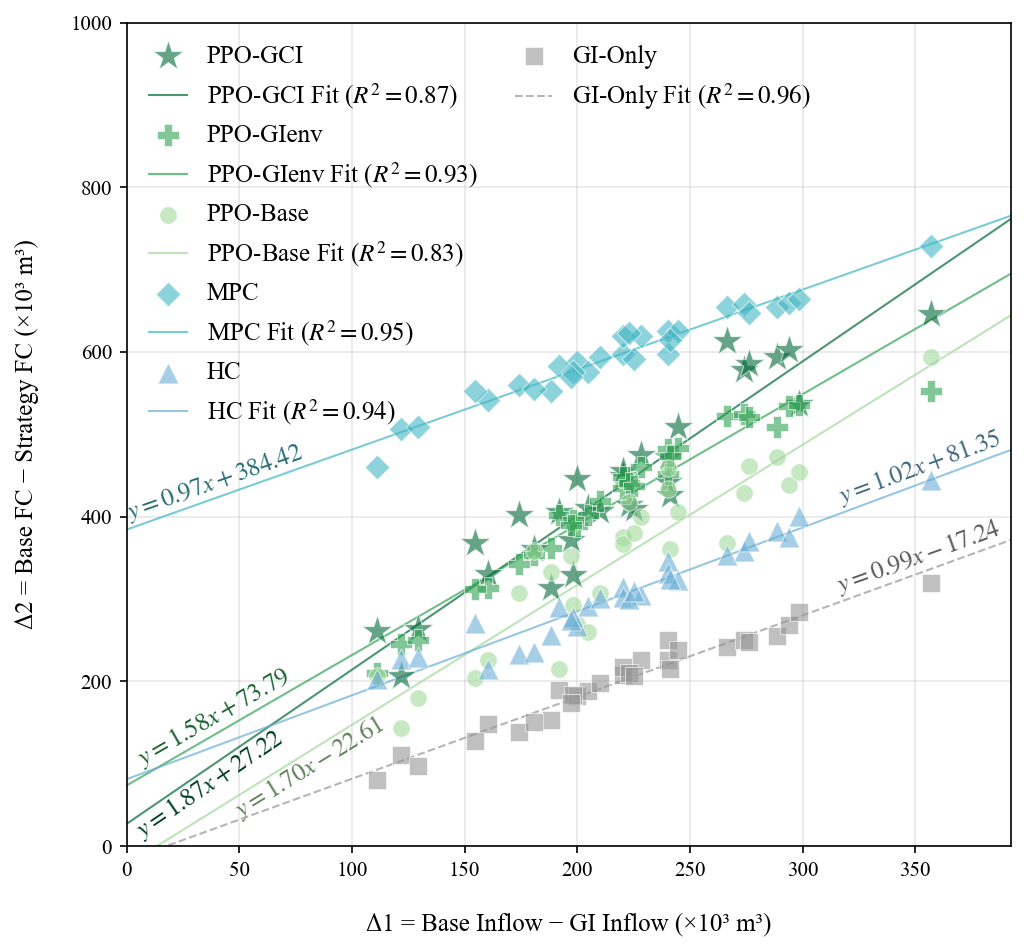

Saved: D:\from_E\School\School\FYP\Green_infrastructure_RTC\Paper\Revision\PPO_Tian\PPO\results_PPO\figures\PPO_delta_scatter_all.png


In [7]:
delta_1_results = []
for i in range(NUM_RAINFALLS_PLOT):
    k = str(i + START_IDX_PLOT)
    base_inflow = get_series(r_base, 'rainfall' + k, ['env4', 'inflow'])[2:] / 1000.0
    gi_inflow = get_series(r_GI, 'rainfall' + k, ['env3', 'inflow'])[2:] / 1000.0
    delta_1_results.append(np.sum(base_inflow - gi_inflow))
delta_1_results = np.asarray(delta_1_results, dtype=float)

def delta2_vs_strategy(strategy_record, rainfall_key, flooding_path, cso_path):
    base_fc = series_flooding_cso(r_base, rainfall_key, ['env4', 'flooding'], ['env4', 'CSO'])
    strat_fc = series_flooding_cso(strategy_record, rainfall_key, flooding_path, cso_path)
    return float(np.sum(base_fc - strat_fc))

delta_2_results_PPO_gci = []
delta_2_results_PPO_gienv = []
delta_2_results_PPO_base = []
delta_2_results_HC = []
delta_2_results_MPC = []
delta_2_results_GI = []

for i in range(NUM_RAINFALLS_PLOT):
    k = str(i + START_IDX_PLOT)
    rk = 'rainfall' + k

    delta_2_results_PPO_gci.append(
        delta2_vs_strategy(r_PPO_gci, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    )
    delta_2_results_PPO_gienv.append(
        delta2_vs_strategy(r_PPO_gienv, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    )
    delta_2_results_PPO_base.append(
        delta2_vs_strategy(r_PPO_base, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    )
    delta_2_results_HC.append(
        delta2_vs_strategy(r_HC, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    )
    delta_2_results_MPC.append(
        delta2_vs_strategy(r_MPC, rk, ['flooding'], ['CSO'])
    )
    delta_2_results_GI.append(
        delta2_vs_strategy(r_GI, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    )

delta_2_results_PPO_gci = np.asarray(delta_2_results_PPO_gci, dtype=float)
delta_2_results_PPO_gienv = np.asarray(delta_2_results_PPO_gienv, dtype=float)
delta_2_results_PPO_base = np.asarray(delta_2_results_PPO_base, dtype=float)
delta_2_results_HC = np.asarray(delta_2_results_HC, dtype=float)
delta_2_results_MPC = np.asarray(delta_2_results_MPC, dtype=float)
delta_2_results_GI = np.asarray(delta_2_results_GI, dtype=float)

specs = [
    ('PPO-GCI', '#006837', '*', 230),
    ('PPO-GIenv', '#31a354', 'P', 120),
    ('PPO-Base', '#a1d99b', 'o', 70),
    ('MPC', '#41b6c4', 'D', 70),
    ('HC', '#6baed6', '^', 100),
    ('GI-Only', '#969696', 's', 70),
]

scatter_edge = 'white'
scatter_edge_lw = 0.5

fig, ax = plt.subplots(figsize=(7, 6.5), dpi=150)

def add_reg_line(ax, x, y, color, label_prefix, linestyle='-'):
    if np.all(~np.isfinite(x)) or np.all(~np.isfinite(y)) or len(x) < 2:
        return None, None, None
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return None, None, None

    slope, intercept, r_val, p_val, std_err = stats.linregress(x[mask], y[mask])

    x_line = np.array([0, max(x[mask]) * 1.1 if np.max(x[mask]) > 0 else 1.0])
    y_line = slope * x_line + intercept
    r2 = r_val ** 2

    line_label = f"{label_prefix} Fit ($R^2={r2:.2f}$)"
    ax.plot(x_line, y_line, linestyle=linestyle, color=color, linewidth=1, alpha=0.7, zorder=2, label=line_label)

    c_rgb = mcolors.to_rgb(color)
    dark_color = tuple([max(0, val * 0.6) for val in c_rgb])

    annotation = {
        'x_start': x_line[0],
        'y_start': y_line[0],
        'x_end': x_line[-1],
        'y_end': y_line[-1],
        'slope': slope,
        'intercept': intercept,
        'equation': (
            f"$y = {slope:.2f}x + {intercept:.2f}$"
            if intercept >= 0
            else f"$y = {slope:.2f}x - {abs(intercept):.2f}$"
        ),
        'color': dark_color,
        'x_shift': 0,
        'above': False,
    }

    return slope, r2, annotation

reg_summaries = []
pending_annotations = []

# Fine-tune these numbers manually if you want to adjust equation positions.
label_settings = {
    'PPO-GCI': {'x_shift': -65, 'above': False},
    'PPO-GIenv': {'x_shift': -75, 'above': True},
    'PPO-Base': {'x_shift': -110, 'above': False},
    'HC': {'x_shift': -390, 'above': True},
    'MPC': {'x_shift': -80, 'above': True},
    'GI-Only': {'x_shift': -390, 'above': True},
}

for label, color, marker, scatter_size in specs:
    yvals = {
        'PPO-GCI': delta_2_results_PPO_gci,
        'PPO-GIenv': delta_2_results_PPO_gienv,
        'PPO-Base': delta_2_results_PPO_base,
        'HC': delta_2_results_HC,
        'MPC': delta_2_results_MPC,
        'GI-Only': delta_2_results_GI,
    }[label]

    ax.scatter(
        delta_1_results, yvals,
        c=color, marker=marker, s=scatter_size, alpha=0.6,
        edgecolors=scatter_edge, linewidth=scatter_edge_lw,
        label=label, zorder=3
    )

    linestyle = '--' if label == 'GI-Only' else '-'
    slope, r2, ann = add_reg_line(
        ax, np.array(delta_1_results), np.array(yvals),
        color, label, linestyle=linestyle
    )
    if ann is not None:
        ann['x_shift'] = label_settings[label]['x_shift']
        ann['above'] = label_settings[label]['above']
        pending_annotations.append(ann)
    reg_summaries.append((label, slope, r2))

ax.set_xlabel('Δ1 = Base Inflow − GI Inflow (×10³ m³)', labelpad=15)
ax.set_ylabel('Δ2 = Base FC − Strategy FC (×10³ m³)', labelpad=15)
ax.grid(True, alpha=0.3)

x_max = max(1e-9, np.nanmax(delta_1_results)) * 1.1
ax.set_xlim(0, x_max if x_max > 0 else 1.0)
ax.set_ylim(0, 1000)

fig.canvas.draw()

gap_pixels = 1

for ann in pending_annotations:
    x_text = ann['x_start'] - ann['x_shift']
    y_text = ann['slope'] * x_text + ann['intercept']

    p1 = ax.transData.transform((ann['x_start'], ann['y_start']))
    p2 = ax.transData.transform((ann['x_end'], ann['y_end']))
    angle = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
    angle_rad = np.radians(angle)

    if ann['above']:
        dx_pixel = -np.sin(angle_rad) * gap_pixels
        dy_pixel = np.cos(angle_rad) * gap_pixels
        va = 'bottom'
    else:
        dx_pixel = np.sin(angle_rad) * gap_pixels
        dy_pixel = -np.cos(angle_rad) * gap_pixels
        va = 'top'

    x_disp, y_disp = ax.transData.transform((x_text, y_text))
    x_final, y_final = ax.transData.inverted().transform((x_disp + dx_pixel, y_disp + dy_pixel))

    ax.text(
        x_final, y_final,
        ann['equation'],
        color=ann['color'], fontsize=12, fontweight='bold',
        rotation=angle,
        rotation_mode='anchor',
        va=va,
        ha='right',
        zorder=4,
    )

handles, labels = ax.get_legend_handles_labels()
hc_idx = labels.index('GI-Only')
n_col1 = hc_idx
n_col2 = len(handles) - hc_idx
n_pad = max(0, n_col1 - n_col2)

blank = plt.Line2D([], [], linestyle='none')
handles = list(handles) + [blank] * n_pad
labels = list(labels) + [''] * n_pad

ax.legend(
    handles, labels,
    loc='upper left',
    ncol=2,
    frameon=False,
    columnspacing=1.5,
    handlelength=1.5,
)

plt.tight_layout()
fig.canvas.draw()
scatter_save_path = FIG_DIR / 'PPO_delta_scatter_all.png'
fig.savefig(scatter_save_path, dpi=300, bbox_inches='tight', pad_inches=0.08)
plt.show()
print('Saved:', scatter_save_path)


C:\Users\tumbl\AppData\Local\Temp\ipykernel_125832\754294267.py:56: RuntimeWarning: overflow encountered in exp
  r_ppo_base = -np.exp(-r_ppo_base)
C:\Users\tumbl\AppData\Local\Temp\ipykernel_125832\754294267.py:57: RuntimeWarning: overflow encountered in exp
  r_ppo_gienv = -np.exp(-r_ppo_gienv)


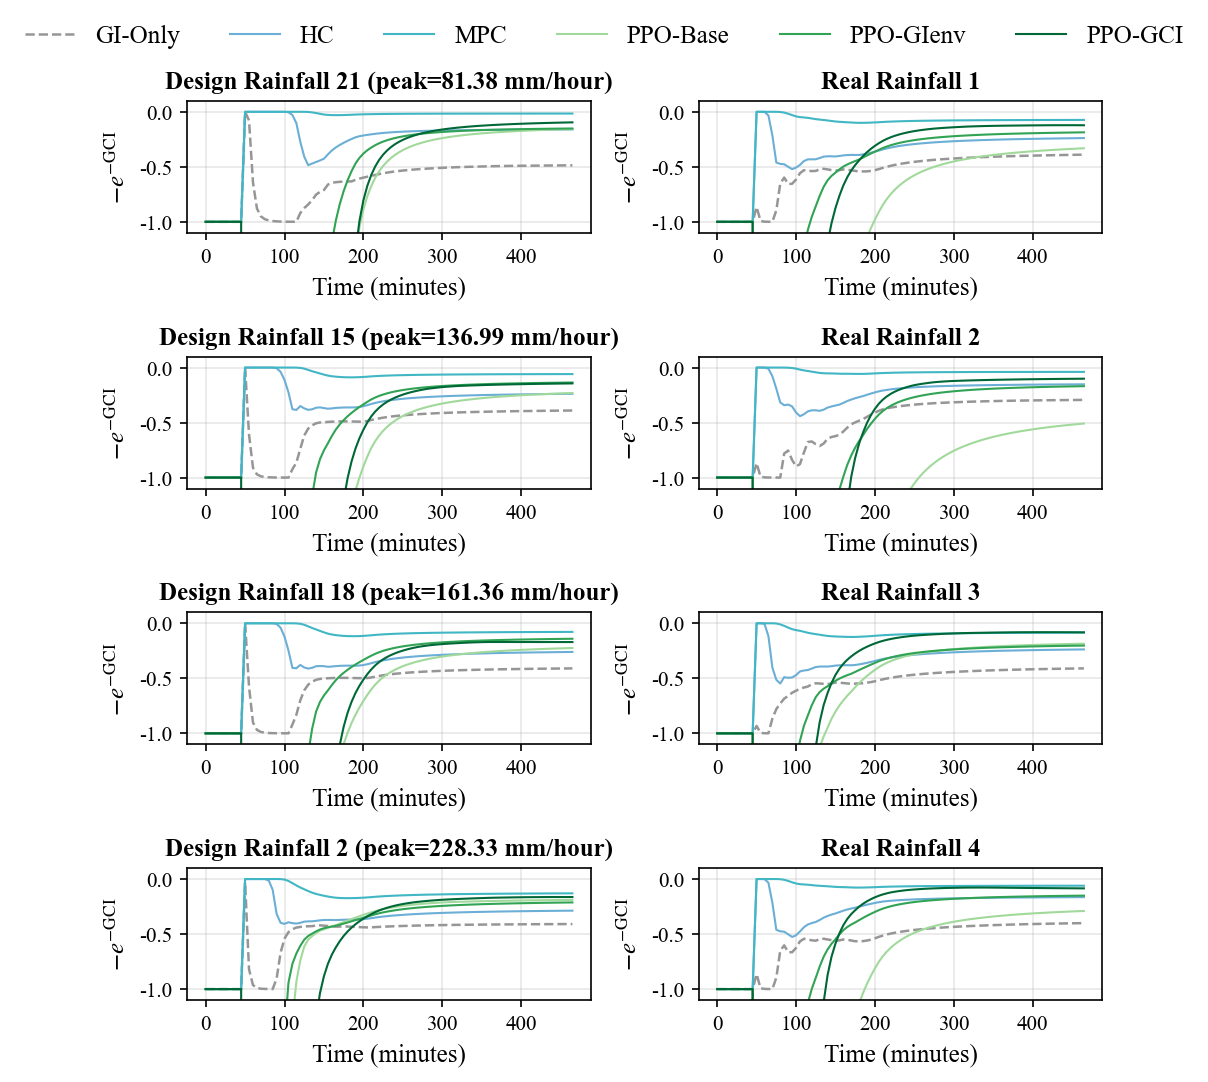

Saved: D:\from_E\School\School\FYP\Green_infrastructure_RTC\Paper\Revision\PPO_Tian\PPO\results_PPO\figures\PPO_GCI_process_all.png


In [8]:
n_pick = 8
n_col = 2
n_row = math.ceil(n_pick / n_col)
figsize = (7, 7)
dpi = 150

fig, ax = plt.subplots(n_row, n_col, figsize=figsize, dpi=dpi, squeeze=False)

handles_labels_collected = False
handles, labels = None, None

for i, ev in enumerate(chosen_events[:n_pick]):
    k = str(ev)
    rk = 'rainfall' + k
    col = i // n_row
    row = i % n_row

    if_real = i >= 4
    base_record = r_base_real if if_real else r_base
    gi_record = r_GI_real if if_real else r_GI
    hc_record = r_HC_real if if_real else r_HC
    mpc_record = r_MPC_real if if_real else r_MPC
    ppo_base_record = r_PPO_base_real if if_real else r_PPO_base
    ppo_gienv_record = r_PPO_gienv_real if if_real else r_PPO_gienv
    ppo_gci_record = r_PPO_gci_real if if_real else r_PPO_gci

    base_in = get_series(base_record, rk, ['env4', 'inflow'])[2:] / 1000.0
    gi_in = get_series(gi_record, rk, ['env3', 'inflow'])[2:] / 1000.0
    delta1_cum = np.cumsum(base_in - gi_in)

    base_fc = series_flooding_cso(base_record, rk, ['env4', 'flooding'], ['env4', 'CSO'])
    gi_fc = series_flooding_cso(gi_record, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    ppo_gci_fc = series_flooding_cso(ppo_gci_record, rk, ['env_new', 'flooding'], ['env_new', 'CSO'])
    ppo_base_fc = series_flooding_cso(ppo_base_record, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    ppo_gienv_fc = series_flooding_cso(ppo_gienv_record, rk, ['env3', 'flooding'], ['env3', 'CSO'])
    hc_fc = series_flooding_cso(hc_record, rk, ['env5', 'flooding'], ['env5', 'CSO'])
    mpc_fc = series_flooding_cso(mpc_record, rk, ['flooding'], ['CSO'])

    delta2_gi_cum = np.cumsum(base_fc - gi_fc)
    delta2_ppo_gci_cum = np.cumsum(base_fc - ppo_gci_fc)
    delta2_ppo_base_cum = np.cumsum(base_fc - ppo_base_fc)
    delta2_ppo_gienv_cum = np.cumsum(base_fc - ppo_gienv_fc)
    delta2_hc_cum = np.cumsum(base_fc - hc_fc)
    delta2_mpc_cum = np.cumsum(base_fc - mpc_fc)

    r_gi = safe_ratio_num_den(delta2_gi_cum, delta1_cum)
    r_ppo_gci = safe_ratio_num_den(delta2_ppo_gci_cum, delta1_cum)
    r_ppo_base = safe_ratio_num_den(delta2_ppo_base_cum, delta1_cum)
    r_ppo_gienv = safe_ratio_num_den(delta2_ppo_gienv_cum, delta1_cum)
    r_hc = safe_ratio_num_den(delta2_hc_cum, delta1_cum)
    r_mpc = safe_ratio_num_den(delta2_mpc_cum, delta1_cum)

    r_gi = -np.exp(-r_gi)
    r_safe = np.clip(r_ppo_gci, -700, 700)
    r_ppo_gci = -np.exp(-r_safe)
    r_ppo_base = -np.exp(-r_ppo_base)
    r_ppo_gienv = -np.exp(-r_ppo_gienv)
    r_hc = -np.exp(-r_hc)
    r_mpc = -np.exp(-r_mpc)

    axl = ax[row, col]

    N = len(r_gi)
    minutes = np.arange(N) * ONE_STEP_MINUTES

    l1, = axl.plot(minutes, r_gi, label='GI-Only', color=color_GI, linestyle='--', linewidth=1.2)
    l2, = axl.plot(minutes, r_hc, label='HC', color=color_HC, linewidth=1.0)
    l3, = axl.plot(minutes, r_mpc, label='MPC', color=color_MPC, linewidth=1.0)
    l4, = axl.plot(minutes, r_ppo_base, label='PPO-Base', color=color_PPO_base, linewidth=1.0)
    l5, = axl.plot(minutes, r_ppo_gienv, label='PPO-GIenv', color=color_PPO_gienv, linewidth=1.0)
    l6, = axl.plot(minutes, r_ppo_gci, label='PPO-GCI', color=color_PPO_gci, linewidth=1.0)

    if not handles_labels_collected:
        handles = [l1, l2, l3, l4, l5, l6]
        labels = [h.get_label() for h in handles]
        handles_labels_collected = True

    local_idx = ev - START_IDX_PLOT
    if i < 4:
        axl.set_title(f'Design Rainfall {str(int(k) - 49)} (peak={peak_values[local_idx]:.2f} mm/hour)', fontweight='bold')
    else:
        axl.set_title(f'Real Rainfall {str(int(k) + 1)}', fontweight='bold')
    axl.set_ylim(-1.1, 0.1)
    axl.set_ylabel(r'$-e^{-\mathrm{GCI}}$')
    axl.set_xlabel('Time (minutes)')
    axl.grid(True, alpha=0.3)

for j in range(n_pick, n_row * n_col):
    fig.delaxes(ax[j // n_col, j % n_col])

fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=len(labels), frameon=False)

plt.tight_layout()
fig.canvas.draw()
gci_save_path = FIG_DIR / 'PPO_GCI_process_all.png'
fig.savefig(gci_save_path, dpi=300, bbox_inches='tight', pad_inches=0.08)
plt.show()
print('Saved:', gci_save_path)
